In [1]:
from casadi import *
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy.io
import pickle
import lightning as L
from sklearn.preprocessing import MinMaxScaler

import math

# Model definition

In [2]:
PARAMETERS = [
    [1.327, 0.0034, 44.223, 2.308, 56.001, 21.840],
    [2.011, 0.0063, 54.185, 2.410, 40.004, 14.624],
    [0.757, 0.0010, 25.271, 1.737, 52.202, 21.516],
    [1.252, 0.0027, 58.349, 2.961, 59.502, 25.429]
]

def ruan_model(parameters):
    # Define the Ruan model from (Ruan et al., 2017), (Abuin et al., 2020)

    # Parameters from (Abuin et al., 2020), identified from 10 in-silico adults
    # in order: endogenous glucose production, glucose effectiveness, insulin sensitivity, carbohidrate factor, time-to-maximum effective insulin concentration, time-of-maximum appearance rate of glucose in gut)

    theta_0 = parameters[0]
    theta_1 = parameters[1]
    theta_2 = parameters[2]
    theta_3 = parameters[3]
    theta_4 = parameters[4]
    theta_5 = parameters[5]

    A = DM([
        [ -theta_1  , -theta_2      , 0         , theta_3   , 0],
        [ 0         , -1/theta_4    , 1/theta_4 , 0         , 0],
        [ 0         , 0             , -1/theta_4, 0         , 0],
        [ 0         , 0             , 0         , -1/theta_5, 1/theta_5],
        [ 0         , 0             , 0         , 0         , -1/theta_5],    
        ])

    # input matrix of u(t) i.e. insulin infusion rate (both basal and boluses) [U/min]
    Bu = DM([[0], [0], [1/theta_4], [0], [0]])
    # input matrix of r(t) u.e. carbohydrate intake rate (CHO) [g/min]
    Br = DM([[0], [0], [0], [0], [1/theta_4]])
    # basal steady-state endogenous glucose production
    E = DM([[theta_0], [0], [0], [0], [0]])
    # input (Blood Glucose Levels)
    C = DM([1, 0, 0, 0, 0])

    # stack the two input vectors into a single input matrix since casadi integrators only allow for one control vector
    B = horzcat(Bu, Br)

    # print(A)
    # print(B)
    # print(E)

    # print(C)

    return {
        "A": A,
        "B": B,
        "Bu": Bu,
        "Br": Br,
        "E": E,
        "C": C
    }

# Input preparation

In [3]:
# utility function to extract
 
def extract_data_from_mat(filename="Data/DMMSR_dataset_OnlyBasal.mat"):
    data = scipy.io.loadmat(filename)
    #print(data["DMMS_export"])

    for i, p in enumerate(data["DMMS_export"][0]):
        # print(np.array(p[1]).T[0])
        
        df = pd.DataFrame({
            "insulin_U" : np.array(p[3]).T[0],
            "meal_g"    : np.array(p[4]).T[0],
            "cgm"       : np.array(p[2]).T[0],
            "time_min"  : np.array(p[1]).T[0]
        })

        name = f"/DMMSR_dataset_OnlyBasal_patient_{i+1}"
        df.to_pickle("Data/pickle"+name+".pkl")
        df.to_csv("Data/CSV"+name+".csv")


In [4]:
def load_uva_padova(filename="Data/pickle/DMMSR_dataset_OnlyBasal.pkl"):
    with open(filename, 'rb') as pkl:
        df = pickle.load(pkl)

    u_seq = np.array(df["insulin_total_U"].astype(float))
    r_seq = np.array(df["meal_g"   ].astype(float))
    cgm_uva = np.array(df["cgm"   ].astype(float))
    tout = np.array(df["time_min"   ].astype(int))

    return {
        "t_out": tout,
        "insulin": u_seq,
        "meals": r_seq,
        "cgm": cgm_uva
    }

# take a subset of uva padova that has not been downsampled yet
def subset_uva_padova(uva, day_start, day_end):
    # days to minutes
    min_start = day_start*24*60
    min_end = day_end*24*60

    return {
        "t_out": uva["t_out"][min_start:min_end],
        "insulin": uva["insulin"][min_start:min_end],
        "meals": uva["meals"][min_start:min_end],
        "cgm": uva["cgm"][min_start:min_end]
    }


In [5]:
def ruan_simulation(parameters, tout, u_insulin, u_meals, plot=False, initial_cgm=100):
    res = ruan_simulation_full(parameters=parameters, tout=tout, u_insulin=u_insulin, u_meals=u_meals, plot=plot, initial_state=[initial_cgm,0,0,0,0])
    cgm_ruan = np.array(res['xf'][0,:].T)

    if plot:
        fig, ax = plt.subplots()
        ax.plot(tout, cgm_ruan) # np.array(df["cgm"])[slicer]

    return cgm_ruan

def ruan_simulation_full(parameters, tout, u_insulin, u_meals, plot=False, initial_state=[100,0,0,0,0]):
    ruan = ruan_model(parameters)
    A = ruan["A"]
    B = ruan["B"]
    E = ruan["E"]

    # continuous time integration with pre-programmed meals and insulin
    # slicer = slice(0,-1)

    x = MX.sym('x', 5)
    U = MX.sym('u', 2)

    ode = {'x':x, 'u': U, 'ode': A@x + B@U + E}
    F = integrator('F','rk',ode, 0, tout ,{})

    # integration only allows for one control vector U, so the u, r have to be stacked
    U_seq = horzcat(u_insulin, u_meals).T

    # integrate

    # print(initial_cgm)
    # print(U_seq)

    res = F(x0=initial_state, u=U_seq)

    cgm_ruan = np.array(res['xf'][0,:].T)

    if plot:
        fig, ax = plt.subplots()
        ax.plot(tout, cgm_ruan) # np.array(df["cgm"])[slicer]

    return res

# Dataset preparation

For one desired patient, load the corresponding UVA/Padova data and perform a simulation using the Ruan model, the collect the needed data for the dataset

In [ ]:
# function overloading does not work in python
# this should use multiple dispatching
# https://stackoverflow.com/questions/6434482/python-function-overloading
 
def compute_dataset(patient_id = 1, downsample_min=5, stride=None, plot=False):
    uvap_data = load_uva_padova(filename=f"Data/pickle/DMMSR_dataset_OnlyBasal_patient_{patient_id}.pkl")
    return downsample_dataset(uvap_data, patient_id = patient_id, downsample_min=downsample_min, stride=stride, plot=plot)

def downsample_dataset(uvap_data, patient_id = 1, downsample_min=5, stride=None, plot=False):
    # reset time vector to ensure CasaDi takes the correct outputs in simulation
    cgm_ruan = ruan_simulation(PARAMETERS[patient_id], np.array([i for i in range(len(uvap_data["t_out"]))]), uvap_data["insulin"], uvap_data["meals"], plot=plot, initial_cgm=uvap_data["cgm"][0])
    original_stride = stride


    if stride == None: stride = downsample_min

    # numpy array, phase shift
    def sample_with_stride(array, downsample_min, stride, save_lengths=False):
        V = []
        L = []
        for i in range(0, downsample_min, stride):
            v = array[i::downsample_min]
            V.append(v)
            L.append(len(v))
        if save_lengths:
            return np.concatenate(V), L
        else:
            return np.concatenate(V)


    # and cast to pytorch tensors
    time_downsample, lengths = sample_with_stride(uvap_data["t_out"], downsample_min, stride, save_lengths=True) #lengths are equal for all arrays, compute them just once
    time_downsample = torch.tensor(time_downsample, dtype=torch.float32).reshape(1, -1)
    cgm_uva_t = torch.tensor(sample_with_stride(uvap_data["cgm"], downsample_min, stride), dtype=torch.float32).reshape(1, -1)
    cgm_ruan_t = torch.tensor(sample_with_stride(cgm_ruan, downsample_min, stride), dtype=torch.float32).reshape(1, -1)

    # due to downsampling, we might miss a meal in the dataset, but see the effects in CGM
    # copy a meal in the -meal_clone_window, +meal_clone_window interval around its index to be sure it gets sampled
    meal_clone_window = downsample_min // 2
    dim = len(uvap_data["meals"])

    shifter = np.eye(dim)
    for i in range(1, meal_clone_window):
        shifter += np.diag(np.ones(dim-i), k=i)
        shifter += np.diag(np.ones(dim-i), k=-i)

    meals_shifted = shifter @ uvap_data["meals"]
    insulin_shifted = shifter @ uvap_data["insulin"]


    # print(shifter.shape, r_seq.shape, meals_shifted.shape)
    meals_t = torch.tensor(sample_with_stride(meals_shifted, downsample_min, stride), dtype=torch.float32).reshape(1, -1)
    insulin_t = torch.tensor(sample_with_stride(insulin_shifted, downsample_min, stride), dtype=torch.float32).reshape(1, -1)

    # meals_t = torch.tensor(sample_with_stride(uvap_data["meals"], downsample_min, stride), dtype=torch.float32).reshape(1, -1)
    # insulin_t = torch.tensor(sample_with_stride(uvap_data["insulin"], downsample_min, stride), dtype=torch.float32).reshape(1, -1)


    print("Downsample dataset: ", original_stride)

    return {
        "time": time_downsample,
        "insulin": insulin_t,
        "meals": meals_t,
        "cgm_ruan": cgm_ruan_t,
        "cgm_uva": cgm_uva_t,
        "downsample": downsample_min,
        "stride": original_stride,
        # a group is a sampling by downsample_min of the original array, each with its own stride
        # this definition is to distinguish from sequences used in the dataset, which are built from groups
        # and consider samples in time from t-L to t
        # "n_groups": int(math.ceil(downsample_min / stride)),
        # the length of the data after downsampling, before stride
        "lengths": lengths,
        "total_length": math.fsum(lengths)
    }

def concat_datasets(datasets):
    return {
        "time": torch.cat([x["time"] for x in datasets], dim=1),
        "insulin": torch.cat([x["insulin"] for x in datasets], dim=1),
        "meals": torch.cat([x["meals"] for x in datasets], dim=1),
        "cgm_ruan": torch.cat([x["cgm_ruan"] for x in datasets], dim=1),
        "cgm_uva": torch.cat([x["cgm_uva"] for x in datasets], dim=1),
        "lengths": [item for x in datasets for item in x["lengths"]],
        "total_length": sum([x["total_length"] for x in datasets])
    }

LSTM layers require sequences as inputs.
Divide the data into input (insulin by controller, meals) and output sequences. Use some days for training, some for validation, some for testing.

In [7]:
import torch
from torch import nn
from torch.nn.utils.rnn import pack_sequence
from torch.utils.data import Dataset, DataLoader

# device = torch.device("cuda") if torch.cuda.is_available() else "cpu"

torch.set_default_dtype(torch.float32)
torch.set_default_device("cuda")
torch.get_default_device()
torch.set_float32_matmul_precision('high')

# Two inputs: u,r
# Create packed sequences of multiple u,r
# Each sequence is obtained by sampling the dataset for 3hours. No overlap between sequences
# https://docs.pytorch.org/docs/2.12/generated/torch.nn.utils.rnn.pack_sequence.html#torch.nn.utils.rnn.pack_sequence
# https://docs.pytorch.org/tutorials/beginner/data_loading_tutorial.html

class SequenceDataset(Dataset):
    def __init__(self, dataset_load, seq_length=50, cgm_uva_mean=None, cgm_uva_std=None, meals_mean=None, meals_std=None, insulin_mean=None, insulin_std=None):
        
        insulin=dataset_load["insulin"]
        meals=dataset_load["meals"]
        cgm_ruan=dataset_load["cgm_ruan"]
        cgm_uva=dataset_load["cgm_uva"]

        assert max(insulin.shape) == max(meals.shape) == max(cgm_ruan.shape) == max(cgm_uva.shape)
        
        # add a current state reference to the data
        # in the MPC formulation, one should have the real cgm levels measured from the patient

        # prenormalize data
        # TODO: when considering boluses insulin will also need to be normalized
        # since now we're only considering basal levels, normalization would return nan

        meals_mean = meals.mean(dim=1, keepdim=True)
        meals_std = meals.std(dim=1, keepdim=True)
        self.cgm_uva_mean = cgm_uva.mean(dim=1, keepdim=True) if cgm_uva_mean is None else cgm_uva_mean
        self.cgm_uva_std = cgm_uva.std(dim=1, keepdim=True) if cgm_uva_std is None else cgm_uva_std
        self.meals_mean = meals.mean(dim=1, keepdim=True) if meals_mean is None else meals_mean
        self.meals_std = meals.std(dim=1, keepdim=True) if meals_std is None else meals_std
        self.insulin_mean = insulin.mean(dim=1, keepdim=True) if insulin_mean is None else insulin_mean
        self.insulin_std = insulin.std(dim=1, keepdim=True) if insulin_std is None else insulin_std

        # data = torch.cat((insulin, meals, cgm_uva), dim=0)
        # data = torch.cat((insulin, meals, (cgm_uva-self.cgm_uva_mean)/self.cgm_uva_std), dim=0)
        # data = torch.cat((insulin, (meals-self.meals_mean)/self.meals_std, (cgm_uva-self.cgm_uva_mean)/self.cgm_uva_std), dim=0)
        data = torch.cat(((insulin-self.insulin_mean)/self.insulin_std, (meals-self.meals_mean)/self.meals_std, (cgm_uva-self.cgm_uva_mean)/self.cgm_uva_std), dim=0)

        # split into sequencies of length seq_length and with a stride of 1
        diff = cgm_uva - cgm_ruan

        self.diff_mean = diff.mean(dim=1, keepdim=True)
        self.diff_std = diff.std(dim=1, keepdim=True)

        # diff = (diff - self.diff_mean)/self.diff_std
        
        x = []
        y = []
        start = 0;
        for i in range(len(dataset_load["lengths"])):
            end = start + dataset_load["lengths"][i] - seq_length - 8
            
            for j in range(start, end):
                _x = data[:, j:(j+seq_length)].T
                _y = diff[:, j+seq_length:j+seq_length+8].T.squeeze()

                x.append(_x)
                y.append(_y)


            # _y = diff[:, start+seq_length:end+seq_length].T
            # y.append(_y)

            start += dataset_load["lengths"][i]

        self.x = torch.stack(x, dim=0)
        self.y = torch.stack(y, dim=0)

        self.len = len(x)

        print(self.x.shape, self.y.shape)


    def __len__(self):
        return self.len

    def __getitem__(self, idx):
        # print(idx)
        return self.x[idx], self.y[idx]

# function overloading does not work in python
# this should use multiple dispatching
# https://stackoverflow.com/questions/6434482/python-function-overloading
def get_dataset_loader(patient_id=1, downsample_min=5, stride=None, train_percent = 0.75, val_percent = 0.15,  test_percent = 0.1, batch_size=64, seq_len=70, cgm_uva_mean=None, cgm_uva_std=None):
    dataset_load = compute_dataset(patient_id=patient_id, stride=stride, downsample_min=downsample_min)

    return {
        "dataset_load": dataset_load,
        "loader": get_loader_from_dataset(dataset_load=dataset_load, train_percent=train_percent, val_percent=val_percent, test_percent=test_percent, batch_size=batch_size, seq_len=seq_len, cgm_uva_mean=cgm_uva_mean, cgm_uva_std=cgm_uva_std)
    }

def get_loader_from_dataset(dataset_load, train_percent = 0.75, val_percent = 0.15, test_percent = 0.1, batch_size=64, seq_len=70, cgm_uva_mean=None, cgm_uva_std=None):
# def get_dataset_loader(dataset_load, train_percent = 0.75, val_percent = 0.15,  test_percent = 0.1, batch_size=64, seq_len=70, cgm_uva_mean=None, cgm_uva_std=None):
#     # Associate each sequence with its respective output
    dataset = SequenceDataset(dataset_load=dataset_load, seq_length=seq_len, cgm_uva_mean=cgm_uva_mean, cgm_uva_std=cgm_uva_std)

    train_idx = int(len(dataset) * train_percent)
    val_idx = train_idx + int(len(dataset) * val_percent)
    test_idx = val_idx + int(len(dataset) * test_percent)

    train_dataset = torch.utils.data.Subset(dataset, range(train_idx))
    val_dataset = torch.utils.data.Subset(dataset, range(train_idx, val_idx))
    test_dataset = torch.utils.data.Subset(dataset, range(val_idx, test_idx))

    # Dataset loader
    train_loader = torch.utils.data.DataLoader(dataset=train_dataset, 
                                            batch_size=batch_size,
                                            shuffle=False)

    val_loader = torch.utils.data.DataLoader(dataset=val_dataset, 
                                            batch_size=batch_size,
                                            shuffle=False)

    test_loader = torch.utils.data.DataLoader(dataset=test_dataset,
                                            batch_size = 999999,
                                            shuffle=False)

    return {
        "full_dataset": dataset,
        "train_loader": train_loader,
        "val_loader": val_loader,
        "test_loader": test_loader,
        "train_sidx": 0,
        "val_sidx": train_idx,
        "test_sidx": val_idx,
        "train_eidx": train_idx-1,
        "val_eidx": val_idx-1,
        "test_eidx": test_idx-1
    }

# Neural network

## Structure

The NN is made of two LSTM layers and two FC layers

In [8]:
from lightning.pytorch.callbacks import Callback, EarlyStopping
from lightning.pytorch.callbacks.early_stopping import EarlyStoppingReason

# Lightning Module for LSTM Model
# https://lightning.ai/lightning-ai/templates/time-series-forecasting-with-pytorch-lightning?section=featured
class NN(L.LightningModule):
    def __init__(self, input_dim=2, hidden_dim=150, output_dim=1, lstm_layers=1, dropout=0.2):
        super().__init__()
        self.save_hyperparameters()
        # torch.manual_seed(2)

        self.input_dim=input_dim
        self.hidden_dim=hidden_dim
        self.output_dim=output_dim
        self.dropout=dropout
        self.lstm_layers = lstm_layers

        # multiple LSTM layers
        # The first layer has two inputs (insulin, meal) and some hidden states
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers=lstm_layers, dropout=dropout, batch_first=True)

        # two readout layers
        # the output is the correction to a single sampling time, so dimension 1
        # self.fc1 = torch.nn.Linear(hidden_dim, output_dim)

        self.fc1 = torch.nn.Linear(hidden_dim, hidden_dim)    
        self.activation = torch.nn.ReLU()
        self.fc2 = torch.nn.Linear(in_features=hidden_dim, out_features=output_dim)

        self.h_0 = None
        self.c_0 = None #tuple initial (hidden, cell)

    def forward(self, x):
        # TODO: this is probably too slow, faster way to avoid this? Edit: does not appear faster without this
        # TODO: this does not even seem to lower the loss, probably the input sequences are already long enough for the network to figure out long term phenomena
        # if self.h_0 is not None and self.c_0 is not None and self.h_0.shape[1] == x.shape[1]:
        #     res, (self.h_0, self.c_0) = self.lstm(x.squeeze(), (self.h_0.detach(), self.c_0.detach()))
        # else:
        #     res, (self.h_0, self.c_0) = self.lstm(x.squeeze())
        # print("In NN")
        # print(x.shape)
        res, (self.h_0, self.c_0) = self.lstm(x.squeeze())

        # done only to account for a batch_size of 1
        res = res.reshape([x.shape[0], x.shape[1], self.hidden_dim])
        # print(res.shape)
        res = self.fc1(res[:, -1, :])
        res = self.activation(res)
        res = self.fc2(res)

        return res

    def training_step(self, batch, batch_idx):
        inputs, targets = batch

        outputs = self(inputs.unsqueeze(-1)).reshape((-1, self.output_dim))
        
        loss = torch.nn.functional.mse_loss(outputs, targets)
        self.log('train_loss', loss, prog_bar=True, on_step=False, on_epoch=True)
        return loss

    def validation_step(self, batch, batch_idx):
        inputs, targets = batch
        outputs = self(inputs.unsqueeze(-1)).reshape((-1, self.output_dim))
        
        loss = torch.nn.functional.mse_loss(outputs, targets)
        self.log('val_loss', loss, prog_bar=True, on_step=False, on_epoch=True)
        return loss

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=0.0002)

# hidden states size is a hyperparameter. The real dynamics of the Ruan model has five state components
# using PyTorch lightning

model = NN(input_dim=3, lstm_layers=2, dropout=0.2, hidden_dim=200, output_dim=8)
# model = NN.load_from_checkpoint("models/reduced-dataset-initial-conditions/checkpoints/epoch=55-step=6048.ckpt")
# model = NN.load_from_checkpoint("models/full_dataset-stride/checkpoints/epoch=20-step=9828.ckpt")


## Training (w/ validation)

In [9]:
class EpochCallback(Callback):
    def on_train_epoch_end(self, trainer, pl_module):
        pl_module.h_0 = None
        pl_module.c_0 = None

early_stop_callback = EarlyStopping(monitor="val_loss", min_delta=2, stopping_threshold=5, patience=20, verbose=False, mode="min")
epoch_callback = EpochCallback()

model.train()
# keeping the hidden and cell states in memory does not have any benefit with smaller datasets
# trainer = L.Trainer(max_epochs=2500, callbacks=[epoch_callback, early_stop_callback], accelerator="gpu")
trainer = L.Trainer(max_epochs=2500, callbacks=[early_stop_callback], accelerator="gpu")

# uvap = load_uva_padova(filename="Data/pickle/DMMSR_dataset_OnlyBasal_patient_1.pkl")
uvap = load_uva_padova(filename="Data/pickle/DMMS_dataset_BasalBolus_patient_1.pkl")

uvap_sub_train = subset_uva_padova(uvap, 0, 5)
uvap_sub_val = subset_uva_padova(uvap, 5, 6)
uvap_sub_test = subset_uva_padova(uvap, 6, 7)
train_dataset = downsample_dataset(uvap_data=uvap_sub_train, patient_id=1, downsample_min=15, stride=1, plot=False)
val_dataset = downsample_dataset(uvap_data=uvap_sub_val, patient_id=1, downsample_min=15, stride=1, plot=False)
test_dataset = downsample_dataset(uvap_data=uvap_sub_test, patient_id=1, downsample_min=15, plot=False)

dataset_load = concat_datasets([train_dataset, val_dataset, test_dataset])
seq_len = 70

# percentages for split
# number of samples to remove (remove seq_len for each group)
ltr_rmv = len(train_dataset["lengths"]) * seq_len
lva_rmv = len(val_dataset["lengths"]) * seq_len
lte_rmv = len(test_dataset["lengths"]) * seq_len

tot_rmv = ltr_rmv + lva_rmv + lte_rmv

ltr = (train_dataset["total_length"] - ltr_rmv) / (dataset_load["total_length"] - tot_rmv)
lva = (val_dataset["total_length"] - lva_rmv) / (dataset_load["total_length"] - tot_rmv)
lte = (test_dataset["total_length"] - lte_rmv) / (dataset_load["total_length"] - tot_rmv)

# reduced dataset + stride
loader = get_loader_from_dataset(dataset_load=dataset_load, seq_len=seq_len, train_percent=ltr, val_percent=lva, test_percent=lte)

trainer.fit(model, loader["train_loader"], loader["val_loader"])

# Access human-readable message
if early_stop_callback.stopping_reason_message:
    print(f"Details: {early_stop_callback.stopping_reason_message}")


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
/home/coder/.local/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Downsample dataset:  1
Downsample dataset:  1
Downsample dataset:  None


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name       | Type   | Params | Mode  | FLOPs
------------------------------------------------------
0 | lstm       | LSTM   | 485 K  | train | 0    
1 | fc1        | Linear | 40.2 K | train | 0    
2 | activation | ReLU   | 0      | train | 0    
3 | fc2        | Linear | 1.6 K  | train | 0    
------------------------------------------------------
527 K     Trainable params
0         Non-trainable params
527 K     Total params
2.110     Total estimated model params size (MB)
4         Modules in train mode
0         Modules in eval mode
0         Total Flops


torch.Size([6318, 70, 3]) torch.Size([6318, 8])
                                                                           

/home/coder/.local/lib/python3.12/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/home/coder/.local/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.
/home/coder/.local/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Epoch 99: 100%|██████████| 93/93 [00:00<00:00, 101.52it/s, v_num=83, val_loss=421.0, train_loss=39.90]   
Details: Monitored metric val_loss did not improve in the last 20 records. Best score: 62.236. Signaling Trainer to stop.


# Testing

torch.Size([25, 8]) torch.Size([25, 8])
torch.Size([32])
(25, 8)
(array([0, 0, 0, 0, 1, 1, 1, 1, 2, 2, 2, 2, 3, 3, 3, 3, 4, 4, 4, 4, 5, 5,
       5, 5, 6, 6, 6, 6, 7, 7, 7, 7]), array([ 0, 15, 30, 45,  0, 15, 30, 45,  0, 15, 30, 45,  0, 15, 30, 45,  0,
       15, 30, 45,  0, 15, 30, 45,  0, 15, 30, 45,  0, 15, 30, 45]))
['00:00', '00:15', '00:30', '00:45', '01:00', '01:15', '01:30', '01:45', '02:00', '02:15', '02:30', '02:45', '03:00', '03:15', '03:30', '03:45', '04:00', '04:15', '04:30', '04:45', '05:00', '05:15', '05:30', '05:45', '06:00', '06:15', '06:30', '06:45', '07:00', '07:15', '07:30', '07:45']


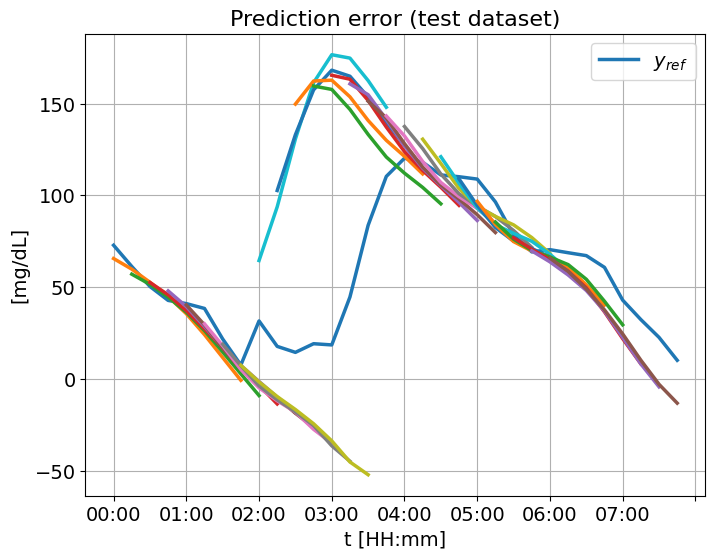

In [ ]:
model.eval()
model.to("cuda:0")
(x, y) = next(iter(loader["test_loader"]))


# ym = model(x)
# x = x.cpu()
ym = model(x)

print(y.shape, ym.shape)

yplot = torch.cat((y[:-1, 0], y[-1, :]))
print(yplot.shape)

y = y.to("cpu").detach().numpy()
ym = ym.to("cpu").detach().numpy()
print(ym.shape)


time = [i*test_dataset["downsample"] for i in range(len(yplot))]
timediv = np.divmod(time, np.array((60,)))
print(timediv)
hours = timediv[0]
minutes = timediv[1]

T = ['{:02d}:{:02d}'.format(int(hours[i]) % 24,  int(minutes[i])) for i in range(len(timediv[0]))]

print(T)

plt.rcParams.update({'figure.figsize': [8, 6]})
plt.rcParams.update({'font.size': 14})

# quick and dirty plots to see how training went
fig, ax = plt.subplots()
ax.plot(T, yplot.cpu().numpy(), linewidth=2.5, label="$y_{ref}$")
for i in range(0, len(ym)):
    ax.plot(T[i:i+8], ym[i], linewidth=2.5)

ax.set_title("Prediction of Neural Correction")
ax.legend()

ax.xaxis.set_major_locator(plt.MaxNLocator(9))
ax.set_ylabel("[mg/dL]")
ax.grid(visible=True)
# ax.set_xlabel("t [HH:mm]")
ax.set_xlabel("t [HH:mm]")
ax.set_title("Prediction error (test dataset)", fontdict={'fontsize': 16})
plt.savefig("prediction_error.pdf", format="pdf", transparent=True)